In [1]:
import pickle
import random
import torch
from tqdm import tqdm
from minf.data import FieldDataset
from minf.models import Decoder, SirenNetUnbatched
from minf.utils import plot_field
from minf.metamol import Metamol
from torch.utils.data import DataLoader
import numpy as np
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [2]:
resolution = 32

pdb_file = "../data/6ega_protein.pdb"
sdf_file = "../data/6ega_ligand.sdf"

properties = [
    "electron_affinity",
    "wigner_seitz_electron_density",
    "electronegativity_allen",
]

mmol, _ = Metamol.from_complex(pdb_file, sdf_file, size=resolution, properties=properties)

[17:08:26] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


In [3]:
mmol.calculate_field()
vector_field = mmol.to_vector_field()

yt : [INFO     ] 2025-02-08 17:08:29,894 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-08 17:08:29,894 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-08 17:08:29,894 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-08 17:08:29,895 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-08 17:08:29,895 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-08 17:08:29,955 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-08 17:08:29,962 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-08 17:08:29,963 Creating volume
yt : [INFO     ] 2025-02-08 17:08:29,980 Creating transfer function
yt : [INFO     ] 2025-02-08 17:08:29,980 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


torch.Size([32, 32, 32, 24])


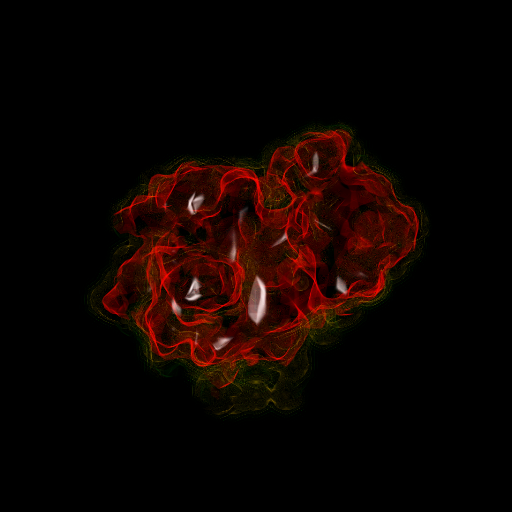

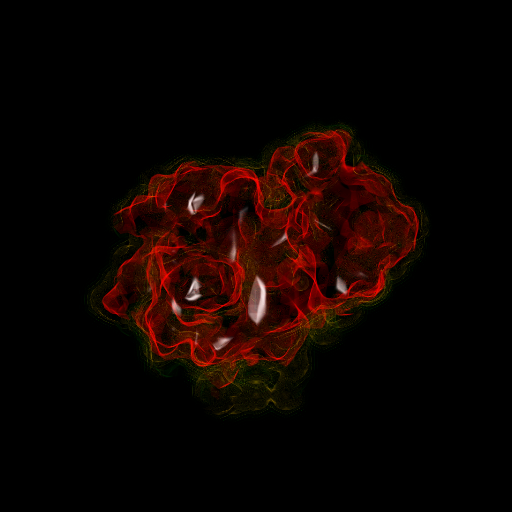

In [4]:
print(vector_field.shape)
plot_field(vector_field[:, :, :, 20])

In [5]:
net = SirenNetUnbatched(
    dim_in=4,
    dim_hidden=128,
    dim_out=1,
    num_layers=5,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

decoder = Decoder(
    net,
    output_shape=[resolution, resolution, resolution, 24, 1],
    # output_shape=[resolution, resolution, resolution, 1, 1],
    latent_dim=64,
    n_shapes=1
)

decoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=decoder.parameters())

/home/daenu/micromamba/envs/minf/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [6]:
for epoch in (pbar := tqdm(range(1000))):
    loss = decoder(vector_field.cuda(), latent_idx=0)
    optim.zero_grad()
    loss.backward()
    optim.step()
    
    torch.save(decoder.state_dict(), "model.pt")
    pbar.set_description(f"Epoch {epoch} (loss: {loss.item()})")

Epoch 94 (loss: 1.2834197762422264):  10%|██████▏                                                          | 95/1000 [00:14<02:14,  6.74it/s]


KeyboardInterrupt: 

In [8]:
i = 0
for batch in dl_test:
    latent = autoencoder.encode(batch.cuda())
    reconstructed = autoencoder.predict(latent).cpu().detach()
    
    for r in reconstructed:
        plot_field(r.flatten(3)[:, :, :, 9])
        print("gt")
        plot_field(fd[i][:, :, :, 9])
        i += 1
    break

NameError: name 'dl_test' is not defined